# Finding diagonal transversal gates in codes
In this notebook, we give examples for finding diagonal transversal gates in the Clifford hierarchy with the tool transversal-gate-finder. Examples include
- triangular 2D color code
- 2x 2D surface code
- 2D color code on torus
- 2x toric code
- tetrahedral 3D color code (quantum Reed-Muller code)
- 3D color code on 3-torus
- 3x 3D toric code on 3-torus
- 2x Haah's cubic code
- 2x bivariate bicycle code
- bivariate bicycle code under folding
- "dual" 3D color code on 3-torus.

In [2]:
import transversal_gate_finder as tg

## S in [7,1,3] triangular color code (Steane code)
Qubits are numbered as follows:

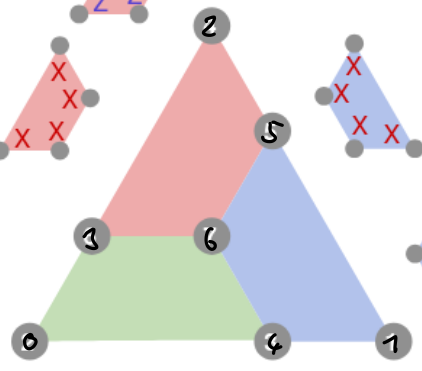

In [3]:
steane_code = tg.GateFinder(7, checks=[[0,3,4,6], [1,4,5,6], [2,3,5,6]], logicals=[[0,2,3]])
steane_code.gates.add_all_single_locs(1)
steane_code.find_gates()
print("Transversal logicals")
steane_code.print_transversal_logicals()
print("Transversal stabilizers")
steane_code.print_physical_stabilizers()

Transversal logicals
order 2
order 4
3/4*[0]

Transversal stabilizers
order 2
1/2*[1], 1/2*[2], 1/2*[3], 1/2*[4]
1/2*[0], 1/2*[1], 1/2*[3], 1/2*[5]
1/2*[1], 1/2*[4], 1/2*[5], 1/2*[6]
order 4



In [4]:
steane_code.print_phys_rep([1]) # find physical representative for 3 times the first found transversal logical operator
steane_code.print_phys_rep_free({(frozenset({0}), 1): 1}) # find physical representative for S gate (if exists)
steane_code.print_phys_rep_free({(frozenset({0}), 2): 1}) # logical T gate doesn't exist

1/4*[0], 1/4*[1], 1/4*[2], 1/4*[3], 1/4*[4], 1/4*[5], 1/4*[6]
3/4*[0], 1/4*[1], 3/4*[2], 3/4*[3], 1/4*[4], 1/4*[5], 1/4*[6]
no transversal implementation


## CZ in 2x surface codes
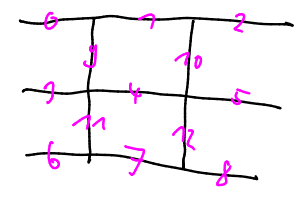

In [6]:
surface_code = tg.GateFinder(13)
surface_code.checks.add_columns([[0, 9, 1], [1, 10, 2], [3, 9, 4, 11], [4, 10, 5, 12], [6, 11, 7], [7, 12, 8]])
surface_code.logicals.add_columns([[0,3,6]])
surface_code2 = tg.GateFinder(13)
surface_code2.checks.add_columns([[0,3,9], [3,11,6], [1,4,9,10], [4,7,11,12], [2,10,5], [5,8,12]])
surface_code2.logicals.add_columns([[0,1,2]])
surface_code_x2 = surface_code + surface_code2
surface_code_x2.gates.add_locs([[i,i+13] for i in range(13)], 1)
surface_code_x2.gates.add_all_single_locs(2)
surface_code_x2.find_gates()
surface_code_x2.print_transversal_logicals()

order 2
1/2*[0, 1]
1/2*[0]
1/2*[1]
order 4
order 8



In [7]:
surface_code_x2.print_phys_rep([1,0,1]) # phsyical gate implementing the first plus last logical gate in the list above
surface_code_x2.print_phys_rep_free({(frozenset({0,1}), 0): 1}) # print physical transversal implementation of logical CZ (if exists)

2/4*[0, 13], 2/4*[1, 14], 2/4*[2, 15], 2/4*[3, 16], 2/4*[4, 17], 2/4*[5, 18], 2/4*[6, 19], 2/4*[7, 20], 2/4*[8, 21], 2/4*[9, 22], 2/4*[10, 23], 2/4*[11, 24], 2/4*[12, 25], 4/8*[13], 4/8*[16], 4/8*[19]
2/4*[0, 13], 2/4*[1, 14], 2/4*[2, 15], 2/4*[3, 16], 2/4*[4, 17], 2/4*[5, 18], 2/4*[6, 19], 2/4*[7, 20], 2/4*[8, 21], 2/4*[9, 22], 2/4*[10, 23], 2/4*[11, 24], 2/4*[12, 25]


## T in [15,1,3] 3D tetrahedral color code (or quantum Reed-Muller code)
<img src="attachment:4da704cf-e8a1-4cad-90f2-e4e237e3377f.png" width="300">

In [8]:
reed_muller = tg.GateFinder(15)
reed_muller.checks.add_columns([[0,14,4,13,6,12,9,10], [1,14,4,13,5,11,8,10], [2,14,5,11,7,12,6,13], [3,14,9,10,8,11,7,12]])
reed_muller.logicals.add_columns([[0,1,2,4,5,6,13]])
reed_muller.gates.add_all_single_locs(2)
reed_muller.find_gates()
reed_muller.print_transversal_logicals()

order 2
order 4
order 8
7/8*[0]



In [9]:
reed_muller.print_phys_rep([7])

7/8*[0], 7/8*[1], 1/8*[2], 3/8*[3], 7/8*[4], 1/8*[5], 1/8*[6], 1/8*[7], 3/8*[8], 3/8*[9], 3/8*[10], 1/8*[11], 1/8*[12], 1/8*[13], 1/8*[14]


## Physical S/logical CZ's in 2D color code on torus

![](markdown_pics/2d_cc.png)

In [10]:
cc_2d = tg.TIGateFinder(2, 2)
cc_2d.checks.add_columns([[((0,0),0), ((0,0),1), ((1,0),0), ((0,1),1), ((0,1),0), ((-1,1),1)]])
cc_2d.other_checks = cc_2d.checks
cc_2d.gates.add_all_single_qubit_gates(1) # S gates on all qubits
cc_2d.gates.add_gates_in_groups([[((0,0),0),((0,0),1),((-1,1),1),((-1,0),1)]], 0, 2) # CZ gates on all qubit pairs that are directly or indirectly neighboring
cc_2d.print_gates()
cc_2d.set_local_gates([[], [((0,0),0), ((0,0),1)]])
cc_2d.find_gates_nonlocal()



Level 0
frozenset({((0, 1), 1), ((0, 0), 1)})
frozenset({((1, -1), 0), ((0, 0), 1)})
frozenset({((1, -1), 1), ((0, 0), 1)})
frozenset({((1, 0), 0), ((0, 0), 1)})
frozenset({((1, 0), 1), ((0, 0), 1)})
frozenset({((0, 0), 0), ((0, 0), 1)})

Level 1
frozenset({((0, 0), 0)})
frozenset({((0, 0), 1)})


In [11]:
cc_2d_finite = cc_2d.as_finite_code([[6,0],[0,6]])
cc_2d_finite.find_logical_action()
cc_2d_finite.print_transversal_logicals()

order 2
1/2*[1, 3], 1/2*[0, 2], 1/2*[0, 1], 1/2*[0], 1/2*[1]
order 4



In [12]:

cc_2d_finite.find_gates()
cc_2d_finite.print_transversal_logicals()
cc_2d_finite.print_phys_rep([0,0,0,0,1])

order 2
1/2*[0], 1/2*[1]
1/2*[1]
1/2*[3], 1/2*[2]
1/2*[3], 1/2*[0], 1/2*[1]
1/2*[1, 3], 1/2*[0, 2], 1/2*[0, 1], 1/2*[0]
order 4

3/4*[0], 1/4*[36], 1/4*[1], 3/4*[37], 1/4*[2], 1/4*[38], 3/4*[3], 1/4*[39], 1/4*[4], 3/4*[40], 1/4*[5], 1/4*[41], 3/4*[6], 3/4*[42], 3/4*[7], 1/4*[43], 1/4*[8], 1/4*[44], 1/4*[9], 1/4*[45], 1/4*[10], 1/4*[46], 1/4*[11], 1/4*[47], 3/4*[12], 3/4*[48], 3/4*[13], 1/4*[49], 3/4*[14], 1/4*[50], 3/4*[15], 1/4*[51], 3/4*[16], 1/4*[52], 1/4*[17], 1/4*[53], 3/4*[18], 3/4*[54], 1/4*[19], 1/4*[55], 3/4*[20], 1/4*[56], 3/4*[21], 1/4*[57], 1/4*[22], 1/4*[58], 1/4*[23], 1/4*[59], 3/4*[24], 1/4*[60], 1/4*[25], 1/4*[61], 3/4*[26], 1/4*[62], 1/4*[27], 1/4*[63], 3/4*[28], 1/4*[64], 1/4*[29], 1/4*[65], 1/4*[30], 1/4*[66], 1/4*[31], 1/4*[67], 1/4*[32], 1/4*[68], 1/4*[33], 1/4*[69], 1/4*[34], 1/4*[70], 1/4*[35], 1/4*[71]


## CZ in 2x 2D toric code

internal qubit number 0: horizontal, internal qubit number 1: vertical

In [13]:
tc_2d = tg.TIGateFinder(2, 2)
tc_2d.checks.add_columns([[((0,0),0),((0,0),1),((1,0),1),((0,1),0)]])
tc_2d.other_checks.add_columns([[((0,0),0),((0,0),1),((-1,0),0),((0,-1),1)]])
tc_2d_x2 = tc_2d + tc_2d
tc_2d_x2.gates.add_all_single_qubit_gates(0)
tc_2d_x2.gates.add_locs([[((0,0),0), ((1,0),3)], [((0,0),1),((0,1),2)]], 0)
tc_2d_x2.find_gates()

In [14]:
tc_2d_x2_finite = tc_2d_x2.as_finite_code([[3,0],[0,3]])
tc_2d_x2_finite.find_logical_action()
tc_2d_x2_finite.print_transversal_logicals()
tc_2d_x2_finite.print_physical_stabilizers()

order 2
1/2*[0]
1/2*[1]
1/2*[2]
1/2*[3]
1/2*[0, 3], 1/2*[1, 2]

order 2



## CCZ in 3x 3D toric code

In [15]:
tc_3d = tg.TIGateFinder(3, 3)
tc_3d.checks.add_columns([[((0,0,0), 0), ((0,0,0), 1), ((0,0,0), 2), ((-1,0,0), 0), ((0,-1,0), 1), ((0,0,-1), 2)]])
tc_3d.other_checks.add_columns([[((0,0,0), 0), ((0,0,0), 1), ((0,1,0), 0), ((1,0,0), 1)], [((0,0,0), 0), ((0,0,0), 2), ((0,0,1), 0), ((1,0,0), 2)], [((0,0,0), 1), ((0,0,0), 2), ((0,0,1), 1), ((0,1,0), 2)]])

tc_3d_x3 = tc_3d + tc_3d + tc_3d
tc_3d_x3.gates.add_locs([[((0,0,0),0), ((1,0,0),4), ((1,1,0),8)],
                    [((0,0,0),0), ((1,0,0),5), ((1,0,1),7)],
                    [((0,0,0),1), ((0,1,0),3), ((1,1,0),8)],
                    [((0,0,0),1), ((0,1,0),5), ((0,1,1),6)],
                    [((0,0,0),2), ((0,0,1),3), ((1,0,1),7)],
                    [((0,0,0),2), ((0,0,1),4), ((0,1,1),6)]], 0)
#tc_3d_x3.gates.add_all_single_qubit_gates(1)
tc_3d_x3.find_gates()

In [16]:
tc_3d_x3_finite = tc_3d_x3.as_finite_code([[3,0,0],[0,3,0],[0,0,3]])
tc_3d_x3_finite.find_logical_action()
tc_3d_x3_finite.print_transversal_logicals()

order 2
1/2*[0, 4, 8], 1/2*[0, 5, 7], 1/2*[1, 3, 8], 1/2*[1, 5, 6], 1/2*[2, 3, 7], 1/2*[2, 4, 6]



In [16]:
tc_3d_x3_finite.find_gates()
tc_3d_x3_finite.print_transversal_logicals()
tc_3d_x3_finite.print_phys_rep([1])

order 2
1/2*[0, 4, 8], 1/2*[0, 5, 7], 1/2*[1, 3, 8], 1/2*[1, 5, 6], 1/2*[2, 3, 7], 1/2*[2, 4, 6]

1/2*[0, 109, 220], 1/2*[0, 136, 199], 1/2*[27, 84, 220], 1/2*[27, 138, 174], 1/2*[54, 90, 199], 1/2*[54, 117, 174], 1/2*[1, 110, 221], 1/2*[1, 137, 200], 1/2*[28, 85, 221], 1/2*[28, 139, 175], 1/2*[55, 91, 200], 1/2*[55, 118, 175], 1/2*[2, 108, 219], 1/2*[2, 135, 198], 1/2*[29, 86, 219], 1/2*[29, 140, 176], 1/2*[56, 92, 198], 1/2*[56, 119, 176], 1/2*[3, 112, 223], 1/2*[3, 139, 202], 1/2*[30, 87, 223], 1/2*[30, 141, 177], 1/2*[57, 93, 202], 1/2*[57, 120, 177], 1/2*[4, 113, 224], 1/2*[4, 140, 203], 1/2*[31, 88, 224], 1/2*[31, 142, 178], 1/2*[58, 94, 203], 1/2*[58, 121, 178], 1/2*[5, 111, 222], 1/2*[5, 138, 201], 1/2*[32, 89, 222], 1/2*[32, 143, 179], 1/2*[59, 95, 201], 1/2*[59, 122, 179], 1/2*[6, 115, 217], 1/2*[6, 142, 205], 1/2*[33, 81, 217], 1/2*[33, 135, 171], 1/2*[60, 96, 205], 1/2*[60, 123, 171], 1/2*[7, 116, 218], 1/2*[7, 143, 206], 1/2*[34, 82, 218], 1/2*[34, 136, 172], 1/2*[61, 97, 

## Physical T/logical CCZ's in 3D color code

We use the truncated octahedral lattice as 3D colex, geometrically deformed into hexagon prisms.
There is one qubit per vertex, one X stabilizer per volume, one Z stabilizer per face, and two independent Z metachecks per volume.

There is one volume, 6 vertices, and 7 faces per unit cell.
We choose one vertex at the top of the volume as the "origin vertex" of the volume/unit cell.

We choose x,y,z basis vectors as shown in the sketch below as orange arrows from the origin vertex of one to another unit cell.

The 6 vertices=qubits per unit cell are the ones of the top horizontal hexagon. They are numbered starting from 0 for the origin vertex and increasing in clockwise order when looking upwards.

The 7 faces are the ones in the top half of the volume. They are numbered as follows: number 0 is the top horizontal hexagon. The following faces are the vertical faces adjacent to the top horizontal hexagon, in clockwise order starting from the origin vertex, such that vertices number i and i+1 are both adjacent to face i+1


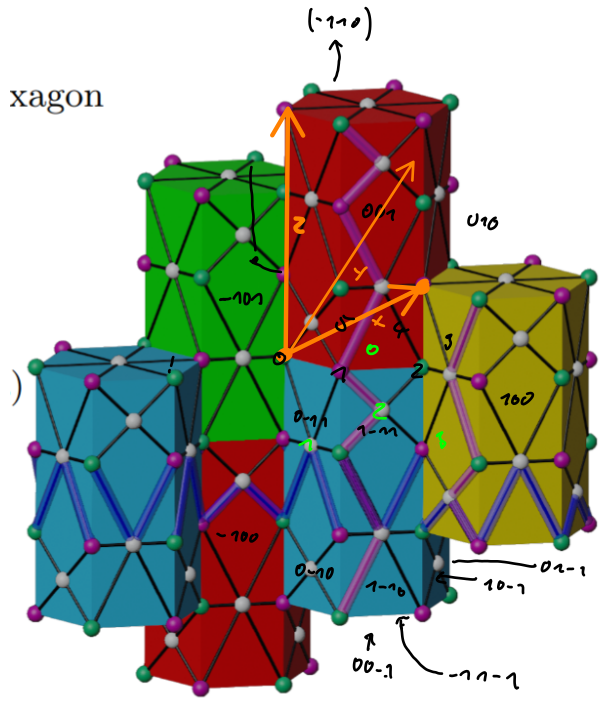

In [24]:
cc_3d = tg.TIGateFinder(6, 3)
cc_3d.checks.add_columns([ # vertices of the volume at (0,0,0)
    [((0,0,0), 0), ((0,0,0), 1), ((0,0,0), 2), ((0,0,0), 3), ((0,0,0), 4), ((0,0,0), 5),
     ((1,-1,0),4), ((1,-1,0), 5), ((0,1,-1),0), ((0,1,-1),1), ((-1,0,0),2), ((-1,0,0),3),
     ((0,-1,0),3), ((0,-1,0),4), ((1,0,-1),0), ((1,0,-1),5), ((-1,1,-1),1), ((-1,1,-1),2),
     ((0,0,-1), 0), ((0,0,-1), 1), ((0,0,-1), 2), ((0,0,-1), 3), ((0,0,-1), 4), ((0,0,-1), 5)]])
cc_3d.other_checks.add_columns([
            [((0,0,0), 0), ((0,0,0), 1), ((0,0,0), 2), ((0,0,0), 3), ((0,0,0), 4), ((0,0,0), 5)], # vertices of horizontal face number 0
            [((0,0,0),0), ((0,0,0),1), ((0,-1,0),3), ((0,-1,0),4), ((-1,0,0),2), ((1,-1,0), 5)], # vertices of face number 1
            [((0,0,0),1), ((0,0,0),2), ((1,-1,0),4), ((1,-1,0), 5)],
            [((0,0,0),2), ((0,0,0),3), ((1,0,-1),0), ((1,0,-1),5), ((1,-1,0),4), ((0,1,-1),1)],
            [((0,0,0),3), ((0,0,0),4), ((0,1,-1),0), ((0,1,-1),1)],
            [((0,0,0),4), ((0,0,0),5), ((-1,1,-1),1), ((-1,1,-1),2), ((0,1,-1),0),((-1,0,0),3)],
            [((0,0,0),0), ((0,0,0),5), ((-1,0,0),2), ((-1,0,0),3)]])
cc_3d.gates.add_all_single_qubit_gates(2)
cc_3d.find_gates()

In [25]:
cc_3d_finite = cc_3d.as_finite_code([[4,0,0],[0,4,0],[0,0,4]])
cc_3d_finite.find_logical_action()
cc_3d_finite.print_transversal_logicals()

order 2
1/2*[1, 3, 7], 1/2*[1, 7, 8], 1/2*[1, 4, 6], 1/2*[2, 3, 7], 1/2*[2, 4, 6], 1/2*[1, 4, 8], 1/2*[2, 4, 8], 1/2*[2, 3, 8], 1/2*[2, 6, 8], 1/2*[0, 3, 7], 1/2*[0, 3, 8], 1/2*[0, 4, 6], 1/2*[0, 6, 7], 1/2*[0, 5, 7], 1/2*[0, 5, 8], 1/2*[1, 5, 8], 1/2*[1, 5, 6], 1/2*[1, 7], 1/2*[1, 8], 1/2*[1, 6], 1/2*[2, 7], 1/2*[6, 7], 1/2*[4, 8], 1/2*[6, 8], 1/2*[0, 7], 1/2*[0, 8], 1/2*[5, 7], 1/2*[5, 8], 1/2*[8]
order 4
order 8



In [20]:
cc_3d_finite.find_gates()
cc_3d_finite.print_transversal_logicals()

order 2
1/2*[2]
1/2*[1]
1/2*[0]
1/2*[1], 1/2*[7], 1/2*[0]
1/2*[6]
1/2*[7], 1/2*[8], 1/2*[6], 1/2*[0]
1/2*[1], 1/2*[3], 1/2*[2], 1/2*[0], 1/2*[5]
1/2*[2], 1/2*[4], 1/2*[6]
1/2*[1], 1/2*[3], 1/2*[7], 1/2*[4], 1/2*[0]
1/2*[8, 1], 1/2*[1, 6], 1/2*[0, 7], 1/2*[0, 8], 1/2*[8], 1/2*[2], 1/2*[0]
1/2*[1, 7], 1/2*[8, 1], 1/2*[1, 6], 1/2*[2, 7], 1/2*[8, 2], 1/2*[8], 1/2*[2], 1/2*[0]
1/2*[1, 7], 1/2*[2, 6], 1/2*[2, 7], 1/2*[0, 6], 1/2*[8], 1/2*[2], 1/2*[0]
1/2*[1, 7], 1/2*[8, 1], 1/2*[1, 4], 1/2*[1, 6], 1/2*[2, 3], 1/2*[2, 4], 1/2*[2, 6], 1/2*[0, 3], 1/2*[0, 7], 1/2*[0, 8], 1/2*[0, 5], 1/2*[1, 5], 1/2*[1], 1/2*[7], 1/2*[2], 1/2*[6], 1/2*[5]
1/2*[1, 3], 1/2*[1, 7], 1/2*[1, 6], 1/2*[2, 6], 1/2*[8, 2], 1/2*[0, 4], 1/2*[0, 6], 1/2*[0, 8], 1/2*[1], 1/2*[7], 1/2*[2], 1/2*[6], 1/2*[0], 1/2*[5]
1/2*[2, 3], 1/2*[2, 7], 1/2*[8, 2], 1/2*[0, 3], 1/2*[0, 4], 1/2*[0, 6], 1/2*[0, 7], 1/2*[0, 5], 1/2*[1], 1/2*[7], 1/2*[8], 1/2*[2], 1/2*[6], 1/2*[0], 1/2*[5]
1/2*[1, 7], 1/2*[8, 1], 1/2*[3, 7], 1/2*[8, 3], 1/2*[1, 

## Third-order gate in the "dual 3D color code"
Dual 3D color code is defined on 3-colex with qubits on faces, two independent X checks per volume, Z checks on vertices.

In [ ]:
cc_3d_dual = tg.TIGateFinder(7, 3)
red_faces = [((0,0,0),0), ((-1,0,0),3), ((1,-1,0),5), ((0,1,-1),1)]
yellow_faces = [((0,0,0),1), ((0,0,0),3), ((0,0,0),5), ((0,0,-1),0)]
green_faces = [((0,0,0),2), ((0,0,0),4), ((0,0,0),6), ((0,-1,0),4), ((1,0,-1),6), ((-1,1,-1),2)]
cc_3d_dual.checks.add_columns([red_faces + green_faces, yellow_faces + green_faces])
cc_3d_dual.other_checks.add_columns(cc_3d.other_checks.transpose())
cc_3d_dual.gates.add_all_single_qubit_gates(2) # T gate on each qubit
# CS and CCZ gates between qubits at faces sharing a vertex
#cc_3d_dual.gates.add_gates_in_groups(cc_3d_dual.other_checks, 1, 2)
cc_3d_dual.gates.add_gates_in_groups([red_faces + yellow_faces + green_faces], 1, 2)
cc_3d_dual.gates.add_gates_in_groups(cc_3d_dual.other_checks, 0, 3)
print(cc_3d_dual.gates.dims)
cc_3d_dual.find_gates()

In [27]:
cc_3d_dual_finite = cc_3d_dual.as_finite_code([[4,0,0],[0,4,0],[0,0,4]])
cc_3d_dual_finite.find_logical_action()
cc_3d_dual_finite.print_transversal_logicals()

order 2
1/2*[2, 4, 7], 1/2*[2, 6, 7], 1/2*[2, 6, 8], 1/2*[0, 5, 6], 1/2*[1, 5, 6], 1/2*[1, 4, 6], 1/2*[3, 4, 6], 1/2*[5, 6, 7], 1/2*[5, 6, 8], 1/2*[2, 5, 8], 1/2*[3, 5, 8], 1/2*[3, 4, 8], 1/2*[4, 5, 8], 1/2*[4, 6, 8], 1/2*[2, 5, 7], 1/2*[1, 3, 7], 1/2*[1, 6, 7], 1/2*[1, 3, 8], 1/2*[1, 4, 7], 1/2*[0, 4, 5], 1/2*[1, 4, 5], 1/2*[0, 1, 4], 1/2*[0, 3, 4], 1/2*[3, 5, 7], 1/2*[4, 5, 7], 1/2*[1, 3, 4], 1/2*[0, 6], 1/2*[1, 6], 1/2*[5, 6], 1/2*[6, 8], 1/2*[5, 8], 1/2*[1, 4], 1/2*[3, 4], 1/2*[4, 5], 1/2*[0, 4], 1/2*[1, 8], 1/2*[4, 8], 1/2*[1, 7], 1/2*[5, 7], 1/2*[6], 1/2*[4]
order 4
order 8



In [16]:
cc_3d_dual_finite.find_gates()
cc_3d_dual_finite.print_transversal_logicals()

order 2
1/2*[3], 1/2*[2]
1/2*[4], 1/2*[6], 1/2*[1], 1/2*[3]
1/2*[1], 1/2*[2]
1/2*[4], 1/2*[5], 1/2*[2]
1/2*[6], 1/2*[5]
1/2*[6], 1/2*[1]
1/2*[1, 4], 1/2*[3, 4], 1/2*[4, 5], 1/2*[5, 6], 1/2*[4], 1/2*[6]
1/2*[1, 4], 1/2*[2, 4], 1/2*[3, 4], 1/2*[4, 6], 1/2*[1, 6], 1/2*[6], 1/2*[1], 1/2*[5]
1/2*[1, 4], 1/2*[2, 4], 1/2*[2, 5], 1/2*[3, 5], 1/2*[4, 5], 1/2*[5, 6], 1/2*[1, 6], 1/2*[2, 6], 1/2*[1, 3], 1/2*[6], 1/2*[1]
1/2*[4], 1/2*[3], 1/2*[5], 1/2*[8]
1/2*[4], 1/2*[0], 1/2*[3], 1/2*[5], 1/2*[2]
1/2*[0], 1/2*[7], 1/2*[5], 1/2*[2]
1/2*[0, 4], 1/2*[1, 4], 1/2*[4, 7], 1/2*[8, 4], 1/2*[0, 6], 1/2*[1, 6], 1/2*[6, 7], 1/2*[8, 6], 1/2*[3, 7], 1/2*[8, 3], 1/2*[2, 7], 1/2*[8, 2], 1/2*[4], 1/2*[0], 1/2*[1], 1/2*[7], 1/2*[5], 1/2*[2]
1/2*[0, 4], 1/2*[1, 4], 1/2*[4, 7], 1/2*[0, 6], 1/2*[1, 6], 1/2*[6, 7], 1/2*[1, 7], 1/2*[8, 1], 1/2*[2, 7], 1/2*[8, 2], 1/2*[4], 1/2*[6], 1/2*[1], 1/2*[2]
1/2*[0, 4], 1/2*[2, 4], 1/2*[4, 7], 1/2*[8, 4], 1/2*[2, 5], 1/2*[3, 5], 1/2*[0, 6], 1/2*[1, 6], 1/2*[2, 6], 1/2*[3, 6], 1

## 2D color-code spacetime circuit



## CZ gate in two stacked BB codes

BB code in table 3 of arXiv:2308.07915

polynomials $y+y^2+x^3$, $x+x^2+y^3$

In [39]:
bb_123 = tg.twobga_code(2, [[1,0],[2,0],[0,3]], [[0,1],[0,2],[3,0]])
bb_123_x2 = bb_123 + bb_123.inverted_coordinates()
bb_123_x2.gates.add_locs([[((0,0),0), ((0,0),2)], [((0,0),0), ((0,0),3)], [((0,0),1), ((0,0),2)], [((0,0),1), ((0,0),3)]], 1)
bb_123_x2.find_gates()

In [40]:
bb_123_x2_finite = bb_123_x2.as_finite_code([[6,0],[0,6]])
bb_123_x2_finite.find_logical_action()
bb_123_x2_finite.print_transversal_logicals()

order 2
1/2*[3, 22], 1/2*[6, 15], 1/2*[16, 6], 1/2*[6, 22], 1/2*[15, 7], 1/2*[16, 7], 1/2*[20, 7], 1/2*[22, 7], 1/2*[8, 15], 1/2*[8, 16], 1/2*[8, 20], 1/2*[8, 22], 1/2*[11, 15], 1/2*[16, 11], 1/2*[11, 20], 1/2*[18, 3], 1/2*[19, 3], 1/2*[3, 23], 1/2*[21, 6], 1/2*[6, 23], 1/2*[21, 7], 1/2*[8, 19], 1/2*[8, 21], 1/2*[18, 11], 1/2*[11, 23], 1/2*[9, 15], 1/2*[9, 22], 1/2*[10, 22], 1/2*[9, 18], 1/2*[9, 19], 1/2*[9, 21], 1/2*[9, 23], 1/2*[10, 18], 1/2*[10, 19], 1/2*[10, 21], 1/2*[10, 23], 1/2*[17, 6], 1/2*[8, 17], 1/2*[17, 11], 1/2*[0, 21], 1/2*[12, 6], 1/2*[12, 7], 1/2*[0, 18], 1/2*[0, 19], 1/2*[18, 4], 1/2*[19, 4], 1/2*[8, 12], 1/2*[10, 12], 1/2*[5, 22], 1/2*[13, 6], 1/2*[10, 13], 1/2*[1, 18], 1/2*[18, 5], 1/2*[14, 7], 1/2*[11, 14], 1/2*[2, 19], 1/2*[1, 21], 1/2*[1, 23], 1/2*[21, 5], 1/2*[5, 23], 1/2*[2, 20]
order 4



All BB codes are instance of one and single 4D code with different twisted PBC

In [2]:
bb_4d = tg.twobga_code(4, [[0,0,0,0], [0,1,0,0],[0,0,0,1]],[[0,0,0,0],[1,0,0,0],[0,0,1,0]])
bb_4d_x2 = bb_4d + bb_4d.inverted_coordinates()
# Add CS gates between any pairing of the 2x2 qubits per unit cell
bb_4d_x2.gates.add_locs([[((0,0,0,0),0), ((0,0,0,0),2)], [((0,0,0,0),0), ((0,0,0,0),3)], [((0,0,0,0),1), ((0,0,0,0),2)], [((0,0,0,0),1), ((0,0,0,0),3)]], 2)
bb_4d_x2.find_gates()

In [3]:
# compactification lattice that yields the same code as bb_123
compactify_123 = [[6,0,0,0],[0,6,0,0],[3,-1,0,-1],[-1,3,-1,0]]
bb_4d_x2_finite = bb_4d_x2.as_finite_code(compactify_123)
bb_4d_x2_finite.find_logical_action()
bb_4d_x2_finite.print_transversal_logicals()

order 2
1/2*[6, 15], 1/2*[16, 6], 1/2*[9, 15], 1/2*[16, 11], 1/2*[1, 20], 1/2*[1, 21], 1/2*[18, 3], 1/2*[3, 20], 1/2*[18, 6], 1/2*[19, 6], 1/2*[20, 6], 1/2*[21, 6], 1/2*[9, 18], 1/2*[9, 20], 1/2*[9, 21], 1/2*[19, 11], 1/2*[11, 23], 1/2*[10, 15], 1/2*[10, 18], 1/2*[10, 19], 1/2*[10, 20], 1/2*[10, 21], 1/2*[9, 13], 1/2*[8, 18], 1/2*[8, 20], 1/2*[8, 22], 1/2*[8, 23], 1/2*[1, 22], 1/2*[3, 22], 1/2*[11, 12], 1/2*[11, 14], 1/2*[18, 4], 1/2*[19, 4], 1/2*[6, 14], 1/2*[0, 20], 1/2*[0, 22], 1/2*[0, 23], 1/2*[18, 5], 1/2*[20, 5], 1/2*[5, 22], 1/2*[5, 23], 1/2*[13, 7], 1/2*[18, 7], 1/2*[22, 7], 1/2*[23, 7], 1/2*[0, 19], 1/2*[19, 5], 1/2*[19, 7], 1/2*[10, 13], 1/2*[10, 22], 1/2*[11, 13], 1/2*[2, 18], 1/2*[2, 21], 1/2*[12, 7], 1/2*[15, 7], 1/2*[16, 7], 1/2*[17, 6], 1/2*[2, 22], 1/2*[10, 14], 1/2*[8, 12], 1/2*[8, 14], 1/2*[8, 15], 1/2*[2, 23], 1/2*[17, 11]
order 4
order 8



In [ ]:
print(bb_4d_x2_finite.find_phys_rep([1]).e.tostring())

## CZ gate in 2x Haah cubic code

In [4]:
haah_cubic = tg.twobga_code(3, [[0,0,0],[0,0,1],[0,1,0],[1,0,0]], [[0,0,0],[0,1,1],[1,0,1],[1,1,0]])
haah_cubic.gates.add_all_single_qubit_gates(2)
haah_cubic.gates.add_gates_in_coord_group([(0,0,0), (1,0,0)], 1, 2)
haah_cubic.gates.add_gates_in_coord_group([(0,0,0), (0,1,0)], 1, 2)
haah_cubic.gates.add_gates_in_coord_group([(0,0,0), (0,0,1)], 1, 2)
haah_cubic.gates.add_gates_in_coord_group([(0,0,0), (1,0,0)], 0, 3)
haah_cubic.gates.add_gates_in_coord_group([(0,0,0), (0,1,0)], 0, 3)
haah_cubic.gates.add_gates_in_coord_group([(0,0,0), (0,0,1)], 0, 3)
haah_cubic.find_gates()

haah_cubic_finite = haah_cubic.as_finite_code([[8,0,0],[0,8,0],[3,3,-1]])
haah_cubic_finite.find_logical_action()
haah_cubic_finite.print_transversal_logicals()

order 2
order 4
order 8



In [5]:
haah_cubic_finite.find_gates()
haah_cubic_finite.print_transversal_logicals()

order 2
1/2*[9], 1/2*[10], 1/2*[11], 1/2*[4], 1/2*[5]
1/2*[4], 1/2*[5], 1/2*[3]
1/2*[9], 1/2*[10], 1/2*[11], 1/2*[4], 1/2*[3]
1/2*[9], 1/2*[10], 1/2*[1], 1/2*[11], 1/2*[3], 1/2*[2]
1/2*[9], 1/2*[10], 1/2*[11], 1/2*[5], 1/2*[3]
1/2*[1], 1/2*[0]
1/2*[9], 1/2*[10], 1/2*[0], 1/2*[4], 1/2*[5], 1/2*[3], 1/2*[2]
1/2*[8], 1/2*[6], 1/2*[9], 1/2*[10], 1/2*[11], 1/2*[0], 1/2*[4], 1/2*[5], 1/2*[3]
1/2*[9], 1/2*[1], 1/2*[0], 1/2*[4], 1/2*[5], 1/2*[3]
1/2*[7], 1/2*[8], 1/2*[0], 1/2*[4], 1/2*[3]
1/2*[7], 1/2*[8], 1/2*[6], 1/2*[10], 1/2*[1], 1/2*[11], 1/2*[5], 1/2*[3], 1/2*[2]
1/2*[7], 1/2*[6], 1/2*[9], 1/2*[1], 1/2*[3]
1/2*[4, 7], 1/2*[5, 8], 1/2*[2, 9], 1/2*[3, 9], 1/2*[3, 6], 1/2*[0, 9], 1/2*[1, 9], 1/2*[9, 11], 1/2*[0, 10], 1/2*[1, 11], 1/2*[3, 10], 1/2*[4, 10], 1/2*[10, 11], 1/2*[3, 11], 1/2*[0, 3], 1/2*[2, 4], 1/2*[3, 4], 1/2*[2, 5], 1/2*[0, 4], 1/2*[0, 5], 1/2*[4, 5], 1/2*[2, 3], 1/2*[9], 1/2*[10], 1/2*[0], 1/2*[4], 1/2*[5], 1/2*[3], 1/2*[2]
order 4
order 8



In [8]:
haah_cubic_finite.find_phys_rep([0,0,0,0,0,0,0,0,0,0,0,0,1]).e.tostring()

'0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2

## Folding gate in [[98,6,10]] BB code
See figure 3.a in [Eberhardt+Steffan 2024](https://arxiv.org/abs/2407.03973)
horizontal: (0,1), (3,0), (4,0)
vertical: (1,0), (0,3), (0,4)

In [3]:
bb_134 = tg.twobga_code(2,[(0,1),(3,0),(4,0)], [(1,0),(0,3),(0,4)])
bb_134.gates.add_all_single_qubit_gates(1)

logical_coordinates = [(0,0),(1,0),(2,0),(5,0),(0,1),(1,1),(2,1),(5,1),(1,2),(3,2),(4,2),(5,2),(1,3),(2,3),(3,3),(6,3),(1,5),(2,5),(3,5),(6,5),(1,6),(3,6),(4,6),(5,6)] # coordinates for a single horizontal X logical
logicals = [{(coord,0) for coord in logical_coordinates}, {((y,x),1) for x,y in logical_coordinates}]
cs_folding_locations = [{((x,y),orient),((-1-y,-1-x),orient)} for x in range(7) for y in range(6-x) for orient in [0,1]]
bb_134_finite = bb_134.as_finite_code([[7,0],[0,7]], auto_logicals = False, ti_logicals = logicals, manual_gates=[cs_folding_locations])
bb_134_finite.logicals.remove_redundant_columns(bb_134_finite.checks)
bb_134_finite.find_gates()
bb_134_finite.print_transversal_logicals()

order 2
1/2*[0], 1/2*[1], 1/2*[5]
1/2*[1], 1/2*[2], 1/2*[3]
1/2*[4], 1/2*[0], 1/2*[1], 1/2*[5], 1/2*[3]
1/2*[4], 1/2*[1], 1/2*[5], 1/2*[2], 1/2*[3]
1/2*[0], 1/2*[1], 1/2*[5], 1/2*[2]
order 4
1/2*[2, 4], 1/2*[0, 4], 1/2*[3, 5], 1/2*[1, 5], 1/4*[4], 2/4*[1], 3/4*[5], 3/4*[2], 3/4*[3]

